In [24]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

In [25]:
# Təkrarlanabilən nəticə üçün
np.random.seed(42)

# Dataset yaratmaq
data = {
    "Student_ID": range(1, 101),
    "Math_Score": np.random.randint(40, 100, 100),
    "Reading_Score": np.random.randint(35, 100, 100),
    "Writing_Score": np.random.randint(30, 100, 100),
    "Study_Hours": np.random.normal(10, 3, 100).round(1),
    "Gender": np.random.choice(["Male", "Female"], 100)
}

df = pd.DataFrame(data)
df

,Student_ID,Math_Score,Reading_Score,Writing_Score,Study_Hours,Gender
0,1,78,96,97,11.8,Female
1,2,91,74,84,4.2,Female
2,3,68,87,85,11.0,Male
3,4,54,58,46,10.2,Male
4,5,82,60,67,9.3,Male
...,...,...,...,...,...,...
95,96,53,36,59,8.7,Male
96,97,70,87,75,13.7,Female
97,98,87,78,35,6.1,Male
98,99,54,66,66,14.7,Male


In [26]:
#1. Math_Score üçün Orta, Median, Mod, Varians və Standart Sapma hesablayın.

In [27]:
print(f'Math score mean: {df['Math_Score'].mean()}')
print(f'Math score median: {df['Math_Score'].median()}')
print(f'Math score mode: {df['Math_Score'].mode()[0]}')
print(f'Math score variance: {df['Math_Score'].var()}')
print(f'Math score std: {df['Math_Score'].std()}')

Math score mean: 69.58
Math score median: 68.0
Math score mode: 83
Math score variance: 325.1349494949495
Math score std: 18.03149881443441


In [28]:
#2. Math_Score üçün Skewness (asimmetriya) və Kurtosis (yastılıq) hesablayın.

In [32]:
print(f'Skewness: {stats.skew(df['Math_Score'])}')
print(f'Kurtosis: {stats.kurtosis(df['Math_Score'])}')

Skewness: 0.028330532127114637
Kurtosis: -1.2618521802338754


In [ ]:
#3.Tələbənin Gender = Female olduğu halda, Reading_Score ≥ 70 olma ehtimalını tap.

In [38]:
prob = (len(df[(df["Reading_Score"] >= 70) & (df["Gender"] == "Female")]) / len(df[df["Gender"] == "Female"]))
print(f'Prob: {prob}')

Prob: 0.4878048780487805


In [ ]:
#4.Study_Hours paylanmasına əsaslanaraq tələbənin gündə 10 saatdan çox oxuma ehtimalını tap (nisbi tezliklə).

In [40]:
prob = (len(df['Study_Hours'][df['Study_Hours'] > 10])) / (len(df['Study_Hours']))
print(f'Prob: {prob}')

Prob: 0.44


In [11]:
#5. Reading_Score üçün 25-ci, 50-ci və 75-ci percentilləri tapın və hansı qrup tələbələrin yarısından daha yaxşı nəticə göstərdiyini müəyyən et.

In [59]:
Q1 = df["Reading_Score"].quantile(0.25)
Q2 = df["Reading_Score"].quantile(0.50)   
Q3 = df["Reading_Score"].quantile(0.75)
success = df["Reading_Score"][df["Reading_Score"] > Q2].tolist()
print(success)

[96, 74, 87, 94, 75, 79, 99, 97, 69, 69, 75, 68, 82, 96, 71, 78, 69, 99, 81, 76, 85, 97, 86, 77, 70, 93, 76, 79, 96, 91, 78, 96, 96, 96, 96, 71, 85, 78, 93, 86, 96, 92, 86, 73, 90, 93, 88, 87, 78]


In [13]:
#6. Writing_Score üçün IQR metodu ilə outlier-ləri tapın. Outlier tələbələrin sayını yazın.

In [44]:
Q1 = df["Writing_Score"].quantile(0.25)
Q2 = df["Writing_Score"].quantile(0.50)   
Q3 = df["Writing_Score"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df["Writing_Score"] < lower_bound) | (df["Writing_Score"] > upper_bound)]
print(len(outliers))

0


In [15]:
#7.Gennder-ə görə Math_Score-un ortalamasını müqayisə et. Hansı qrupun orta nəticəsinin daha yüksək olduğunu müəyyən edin.

In [50]:
males_avg = df['Math_Score'][df['Gender'] == 'Male'].mean()
females_avg = df['Math_Score'][df['Gender'] == 'Female'].mean()
if males_avg > females_avg:
    print('Males more')
elif males_avg < females_avg:
    print('Females more')
else:
    print('Equal')

Females more


In [17]:
#8. Math_Score, Reading_Score, Writing_Score və Study_Hours arasında korrelasiya matrisini çıxar.
# Ən güclü müsbət korrelasiyanı göstər.

In [19]:
#9.Study_Hours dəyişəni üçün histogram çəkin və paylanmanı şərh edin.

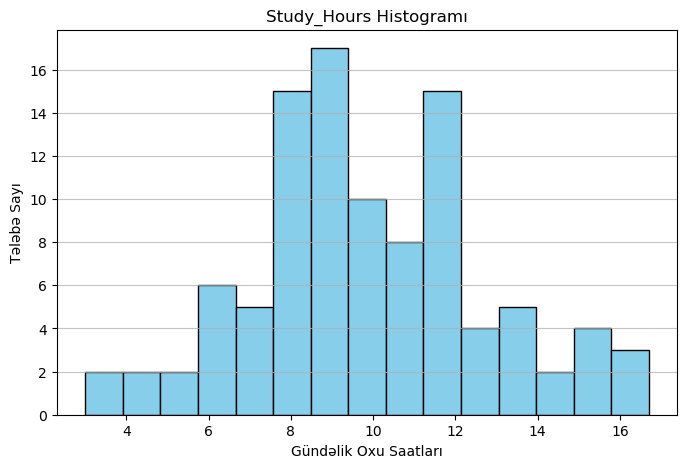

In [51]:
plt.figure(figsize=(8,5))
plt.hist(df["Study_Hours"], bins=15, color='skyblue', edgecolor='black')
plt.title("Study_Hours Histogramı")
plt.xlabel("Gündəlik Oxu Saatları")
plt.ylabel("Tələbə Sayı")
plt.grid(axis='y', alpha=0.75)
plt.show()

In [ ]:
#10.Writing_Score paylanmasını Gender üzrə müqayisə et (iki ayrı histogram və ya boxplot).
# Hər iki qrupun nəticələrində hansı fərqlər var?

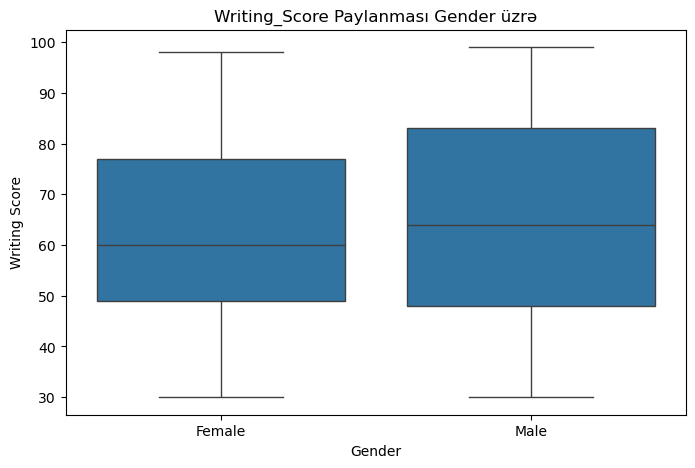

In [55]:
import seaborn as sns
plt.figure(figsize=(8,5))
sns.boxplot(x="Gender", y="Writing_Score", data=df)
plt.title("Writing_Score Paylanması Gender üzrə")
plt.xlabel("Gender")
plt.ylabel("Writing Score")
plt.show()